# NIIT Final Capstone 
## OTT Streaming Platform Viewing Pattern Analysis

**Topic:** Analyse OTT Platform Viewing Patterns to Support Data-Driven Content Decisions (MediaTech)


Use the **Five  cleaned datasets** to perform Python EDA, identify the most important business questions, create appropriate visualizations, and write business narrations/key insights.

**Reference:** The uploaded EDA notebook is used only as a **structure/reference**. It is not used as the data source.

**Data sources used in this notebook**
1. `user_profile_cleaned.xlsx`
2. `content_library_cleaned.xlsx`
3. `viewing_activity_cleaned.xlsx`
4. `subscription_retention_cleaned.xlsx`
5. `ratings_feedback_cleaned.xlsx`

The analysis follows the project business focus: engagement, viewing behaviour, content performance, ratings/feedback, renewal/churn, and audience/platform differences.

In [6]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [7]:
# ============================================================
# 2. LOAD THE FIVE CLEANED DATASETS
# ============================================================
# The notebook expects the five cleaned Excel files in the same folder.
# It supports both the original cleaned names and the "(1)" duplicate names.

from pathlib import Path

DATA_PATH = Path(".")

def find_cleaned_file(base_name):
    candidates = [
        DATA_PATH / f"{base_name}.xlsx",
        DATA_PATH / f"{base_name}(1).xlsx",
    ]
    for path in candidates:
        if path.exists():
            return path
    matches = sorted(DATA_PATH.glob(f"{base_name}*.xlsx"))
    if matches:
        return matches[0]
    raise FileNotFoundError(
        f"Could not find {base_name}.xlsx in {DATA_PATH.resolve()}"
    )

user_profile = pd.read_excel("C:\\Users\\ramya\\OneDrive\\Desktop\\PR\\project-topic-05-main\\Cleaned_Data\\user_profile_cleaned.xlsx")
content_library = pd.read_excel("C:\\Users\\ramya\\OneDrive\\Desktop\\PR\\project-topic-05-main\\Cleaned_Data\\content_library_cleaned.xlsx")
viewing_activity = pd.read_excel("C:\\Users\\ramya\\OneDrive\\Desktop\\PR\\project-topic-05-main\\Cleaned_Data\\viewing_activity_cleaned.xlsx")
subscription_retention = pd.read_excel("C:\\Users\\ramya\\OneDrive\\Desktop\\PR\\project-topic-05-main\\Cleaned_Data\\subscription_retention_cleaned.xlsx")
ratings_feedback = pd.read_excel("C:\\Users\\ramya\\OneDrive\\Desktop\\PR\\project-topic-05-main\\Cleaned_Data\\ratings_feedback_cleaned.xlsx")

print("Datasets loaded successfully.")
print("User profile:", user_profile.shape)
print("Content library:", content_library.shape)
print("Viewing activity:", viewing_activity.shape)
print("Subscription retention:", subscription_retention.shape)
print("Ratings & feedback:", ratings_feedback.shape)

Datasets loaded successfully.
User profile: (2000, 10)
Content library: (17797, 21)
Viewing activity: (30000, 11)
Subscription retention: (2000, 5)
Ratings & feedback: (12000, 5)


In [8]:
# ============================================================
# 3. DATA FRAMING – BASIC STRUCTURE AND SHAPE
# ============================================================
datasets = {
    "User Profile": user_profile,
    "Content Library": content_library,
    "Viewing Activity": viewing_activity,
    "Subscription Retention": subscription_retention,
    "Ratings & Feedback": ratings_feedback
}

summary = pd.DataFrame([
    {
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Cells": int(df.isna().sum().sum()),
        "Duplicate Rows": int(df.duplicated().sum())
    }
    for name, df in datasets.items()
])

display(summary)

print("\nColumn names:")
for name, df in datasets.items():
    print(f"\n{name}:")
    print(df.columns.tolist())

,Dataset,Rows,Columns,Missing Cells,Duplicate Rows
0,User Profile,2000,10,0,0
1,Content Library,17797,21,0,0
2,Viewing Activity,30000,11,0,0
3,Subscription Retention,2000,5,0,0
4,Ratings & Feedback,12000,5,0,0



Column names:

User Profile:
['User_ID', 'Gender', 'Age_Group', 'Region', 'Subscription_Type', 'Subscription_Start_Date', 'Subscription_End_Date', 'Device_Type', 'Engagement_Level', 'Subscription_Date_Flag']

Content Library:
['Show_ID', 'Content_ID', 'Content_Type', 'Title', 'Director', 'Cast', 'Country', 'Release_Year', 'Content_Rating', 'Duration', 'Genres', 'Description', 'Platform', 'Duration_Minutes', 'Content_Age_Years', 'Numeric_Rating', 'Popularity_Score', 'Engagement_Proxy', 'Is_Recent', 'Genre_Count', 'Duration_Quality_Flag']

Viewing Activity:
['Viewing_Record_ID', 'Session_ID', 'User_ID', 'Content_ID', 'View_Date', 'Watch_Duration_Minutes', 'Completion_Percentage', 'Paused_Times', 'Rewatched_Flag', 'Time_of_Day', 'Device_Type']

Subscription Retention:
['User_ID', 'Subscription_Type', 'Monthly_Fee', 'Renewal_Status', 'Churn_Flag']

Ratings & Feedback:
['User_ID', 'Content_ID', 'Rating', 'Liked_Flag', 'Feedback_Category']


In [9]:
# ============================================================
# 4. DATA QUALITY VALIDATION
# ============================================================
quality_checks = {
    "User_ID missing": user_profile["User_ID"].isna().sum(),
    "Content_ID missing": content_library["Content_ID"].isna().sum(),
    "Viewing_Record_ID missing": viewing_activity["Viewing_Record_ID"].isna().sum(),
    "Watch duration <= 0": (viewing_activity["Watch_Duration_Minutes"] <= 0).sum(),
    "Completion outside 0-100": ((viewing_activity["Completion_Percentage"] < 0) |
                                  (viewing_activity["Completion_Percentage"] > 100)).sum(),
    "Rating outside 1-5": ((ratings_feedback["Rating"] < 1) |
                           (ratings_feedback["Rating"] > 5)).sum(),
    "Invalid churn flag": (~subscription_retention["Churn_Flag"].isin([0, 1])).sum()
}

quality_df = pd.DataFrame(list(quality_checks.items()), columns=["Check", "Invalid Count"])
display(quality_df)

print("These checks confirm that the cleaned files are suitable for EDA.")

,Check,Invalid Count
0,User_ID missing,0
1,Content_ID missing,0
2,Viewing_Record_ID missing,0
3,Watch duration <= 0,0
4,Completion outside 0-100,0
5,Rating outside 1-5,0
6,Invalid churn flag,0


These checks confirm that the cleaned files are suitable for EDA.


## 5. DATA FRAMING TECHNIQUES

The main Pandas data-framing techniques used in this Sprint are:

- **Filtering:** select relevant records/groups.
- **Sorting:** identify top/bottom performers.
- **GroupBy + aggregation:** compare business segments.
- **Merge:** connect the five datasets through `User_ID` and `Content_ID`.
- **Pivot tables:** create compact multi-dimensional summaries.
- **Crosstab:** compare categorical variables such as churn and subscription.
- **Explode:** split comma-separated genres so each genre can be analysed independently.

These techniques turn the cleaned raw tables into analysis-ready business views.

In [10]:
# ============================================================
# 6. CREATE ANALYSIS-READY MERGED DATAFRAME
# ============================================================
# User attributes
analysis_df = viewing_activity.merge(
    user_profile[
        ["User_ID", "Gender", "Age_Group", "Region",
         "Subscription_Type", "Device_Type", "Engagement_Level"]
    ],
    on="User_ID",
    how="left",
    suffixes=("", "_User")
)

# Content attributes
analysis_df = analysis_df.merge(
    content_library[
        ["Content_ID", "Content_Type", "Title", "Genres", "Platform",
         "Release_Year", "Content_Rating", "Duration_Minutes",
         "Popularity_Score", "Numeric_Rating"]
    ],
    on="Content_ID",
    how="left"
)

# Subscription/churn attributes
analysis_df = analysis_df.merge(
    subscription_retention[
        ["User_ID", "Monthly_Fee", "Renewal_Status", "Churn_Flag"]
    ],
    on="User_ID",
    how="left",
    suffixes=("", "_Subscription")
)

print("Analysis dataframe shape:", analysis_df.shape)
display(analysis_df.head())

Analysis dataframe shape: (30000, 29)


,Viewing_Record_ID,Session_ID,User_ID,Content_ID,View_Date,Watch_Duration_Minutes,Completion_Percentage,Paused_Times,Rewatched_Flag,Time_of_Day,Device_Type,Gender,Age_Group,Region,Subscription_Type,Device_Type_User,Engagement_Level,Content_Type,Title,Genres,Platform,Release_Year,Content_Rating,Duration_Minutes,Popularity_Score,Numeric_Rating,Monthly_Fee,Renewal_Status,Churn_Flag
0,1,S723607,U0001,C08386,2024-09-17,5,13,0,Y,Morning,Smart TV,Female,50+,West,Free Trial,Smart TV,High,Movie,Young Love (at Bowery Ballroom),Music Videos and Concerts,AmazePrime,2007,NR,37,-8.00,0,0,Not Renewed,1
1,2,S221333,U0001,C03723,2022-09-04,84,14,2,N,Evening,Smart TV,Female,50+,West,Free Trial,Smart TV,High,TV Show,Cinta Teruna Kimchi,"International TV Shows, TV Dramas",NetStream,2016,TV-PG,600,1.00,0,0,Not Renewed,1
2,3,S853250,U0001,C15629,2022-05-02,74,98,0,N,Night,Smart TV,Female,50+,West,Free Trial,Smart TV,High,Movie,Vacuuming Completely Nude in Paradise,Drama,AmazePrime,2001,18+,75,5.20,18,0,Not Renewed,1
3,4,S562018,U0001,C01926,2025-02-02,97,76,0,Y,Afternoon,Smart TV,Female,50+,West,Free Trial,Smart TV,High,Movie,Dhh,"Children & Family Movies, Dramas, Internationa...",NetStream,2017,TV-G,127,2.00,0,0,Not Renewed,1
4,5,S283293,U0001,C04236,2022-05-03,461,76,3,N,Afternoon,Smart TV,Female,50+,West,Free Trial,Smart TV,High,TV Show,Paap-O-Meter,"Kids' TV, TV Comedies",NetStream,2017,TV-Y7,600,5.00,7,0,Not Renewed,1


In [11]:
# ============================================================
# 7. FILTERING, SORTING AND AGGREGATION EXAMPLES
# ============================================================

# Filtering: highly engaged viewing records
high_completion = analysis_df[analysis_df["Completion_Percentage"] >= 75]

# Sorting: top viewing records by watch duration
top_watch_records = analysis_df.sort_values(
    "Watch_Duration_Minutes", ascending=False
).head(10)

# Aggregation: platform performance
platform_summary = (
    analysis_df.groupby("Platform")
    .agg(
        Views=("Viewing_Record_ID", "count"),
        Watch_Hours=("Watch_Duration_Minutes", lambda x: x.sum() / 60),
        Avg_Completion=("Completion_Percentage", "mean")
    )
    .sort_values("Watch_Hours", ascending=False)
)

print("High-completion records:", len(high_completion))
print("\nTop watch-duration records:")
display(top_watch_records[["Viewing_Record_ID", "User_ID", "Content_ID",
                            "Watch_Duration_Minutes", "Completion_Percentage"]])

print("\nPlatform summary:")
display(platform_summary.round(2))

High-completion records: 8221

Top watch-duration records:


,Viewing_Record_ID,User_ID,Content_ID,Watch_Duration_Minutes,Completion_Percentage
8301,8302,U0554,C09163,12169,96
12763,12764,U0851,C16562,10700,93
8643,8644,U0577,C08978,10419,59
23603,23604,U1574,C02317,8360,92
13943,13944,U0930,C11846,8193,97
22415,22416,U1495,C09035,7795,68
5994,5995,U0400,C01275,7589,97
16915,16916,U1128,C04094,7175,91
13066,13067,U0872,C09163,7079,56
20869,20870,U1392,C16425,6557,91



Platform summary:


,Views,Watch_Hours,Avg_Completion
Platform,,,
NetStream,14174,"48,229.52",51.22
AmazePrime,13812,"34,359.92",53.02
DizPlay+,2014,"7,909.43",55.83


In [ ]:
# ============================================================
# 8. PIVOT TABLE
# ============================================================

age_subscription_pivot = pd.pivot_table(
    analysis_df,
    index="Age_Group",
    columns="Subscription_Type",
    values="Viewing_Record_ID",
    aggfunc="count",
    fill_value=0
)

churn_subscription = pd.crosstab(
    subscription_retention["Subscription_Type"],
    subscription_retention["Churn_Flag"],
    normalize="index"
) * 100

print("Age group × subscription viewing volume:")
display(age_subscription_pivot)

print("\nChurn distribution within subscription type (%):")
display(churn_subscription.round(2))

Age group × subscription viewing volume:


Subscription_Type,Basic,Free Trial,Premium
Age_Group,,,
18-25,2400,2430,2415
26-35,2280,2655,2565
36-50,2625,2550,2445
50+,2595,2580,2460



Churn distribution within subscription type (%):


Churn_Flag,0,1
Subscription_Type,,
Basic,57.58,42.42
Free Trial,29.07,70.93
Premium,81.03,18.97


# 9. IMPORTANT BUSINESS QUESTIONS FOR SPRINT 5

The following questions are selected because they directly support the OTT business problem and can produce clear dashboard-level decisions:

1. **Which platforms generate the strongest viewing engagement?**
2. **Do Movies or TV Shows generate more meaningful engagement?**
3. **Which subscription plans have the highest churn risk?**
4. **How does viewing behaviour differ between churned and retained users?**
5. **Which genres attract the most viewing activity and watch hours?**
6. **Which devices and times of day are associated with stronger completion?**
7. **Does watch duration meaningfully relate to completion percentage?**
8. **What does audience rating/feedback reveal about content satisfaction?**
9. **Which age groups and engagement levels represent retention opportunities?**
10. **Which individual content titles are the strongest performers?**

For a **minimal dashboard**, the first 8 questions are sufficient. Questions 9–10 can be supporting analysis.

## 10. UNIVARIATE EDA – AUDIENCE PROFILE

### Business purpose
Understand who the OTT audience is before comparing behaviour and retention across segments.

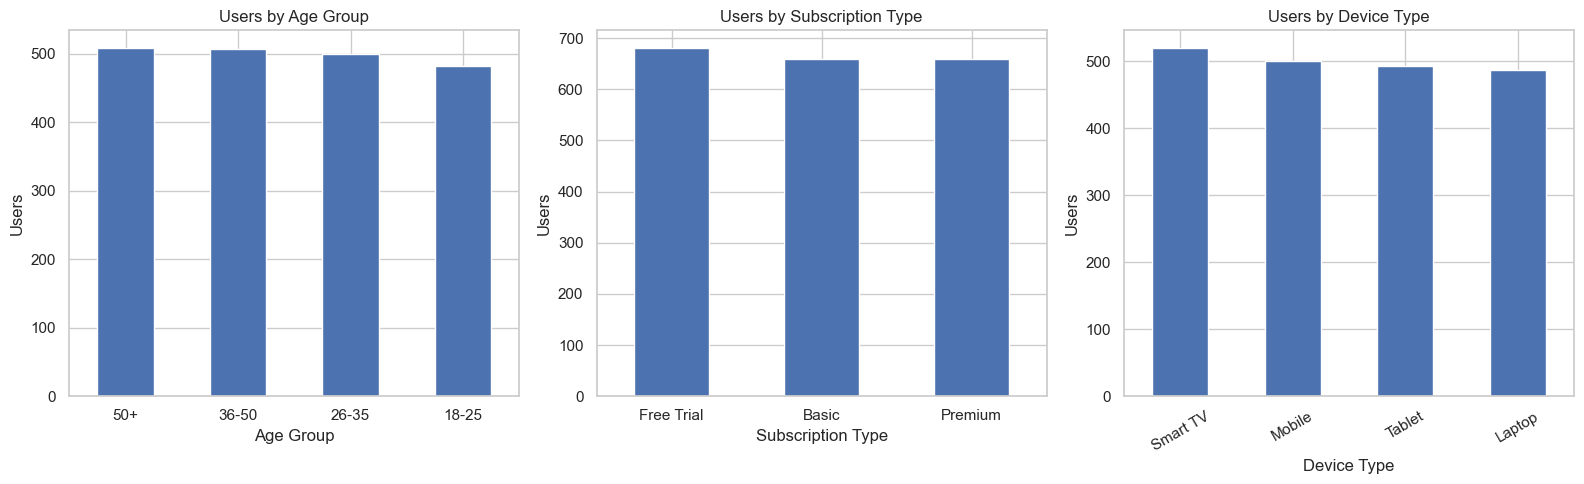

Narration: The audience profile shows how users are distributed across age, subscription and device segments. These segments become the basis for deeper retention and engagement comparisons.


In [13]:
# Audience distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

user_profile["Age_Group"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Users by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Users")
axes[0].tick_params(axis="x", rotation=0)

user_profile["Subscription_Type"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Users by Subscription Type")
axes[1].set_xlabel("Subscription Type")
axes[1].set_ylabel("Users")
axes[1].tick_params(axis="x", rotation=0)

user_profile["Device_Type"].value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Users by Device Type")
axes[2].set_xlabel("Device Type")
axes[2].set_ylabel("Users")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("Narration: The audience profile shows how users are distributed across age, subscription and device segments. "
      "These segments become the basis for deeper retention and engagement comparisons.")

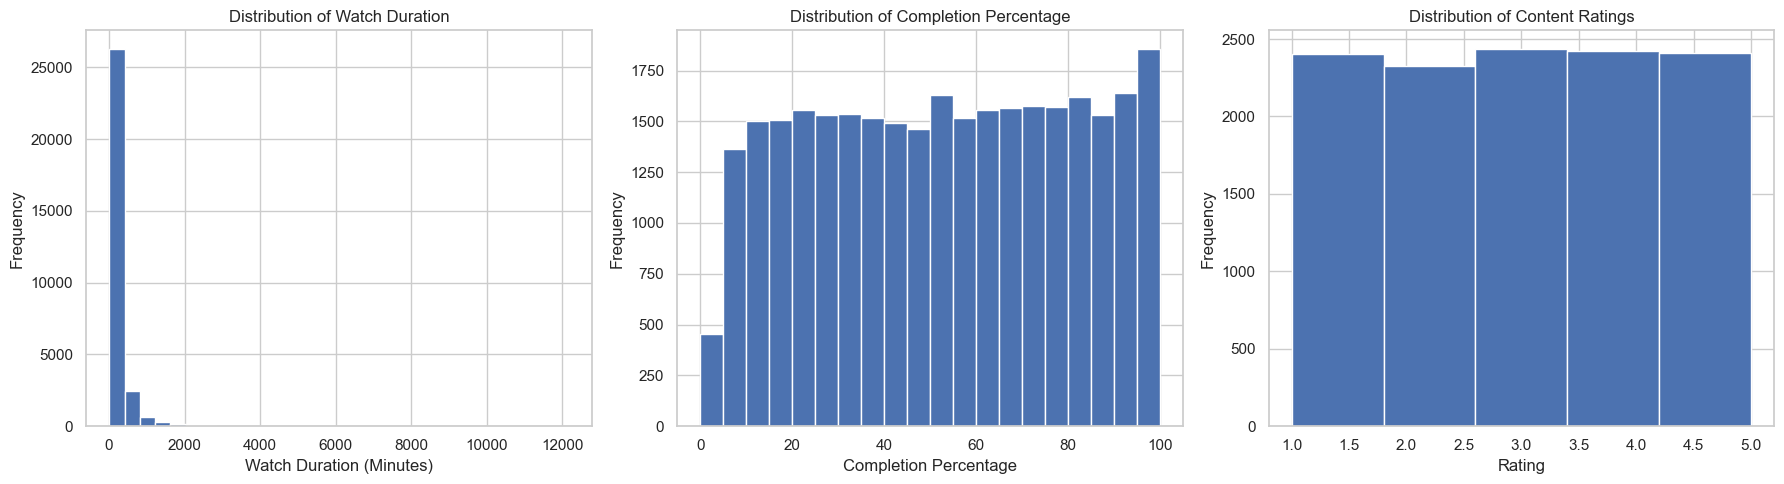

In [29]:
# ============================================================
#  HISTOGRAMS – NUMERICAL VARIABLE DISTRIBUTIONS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Watch Duration
axes[0].hist(
    viewing_activity["Watch_Duration_Minutes"].dropna(),
    bins=30
)
axes[0].set_title("Distribution of Watch Duration")
axes[0].set_xlabel("Watch Duration (Minutes)")
axes[0].set_ylabel("Frequency")

# Completion Percentage
axes[1].hist(
    viewing_activity["Completion_Percentage"].dropna(),
    bins=20
)
axes[1].set_title("Distribution of Completion Percentage")
axes[1].set_xlabel("Completion Percentage")
axes[1].set_ylabel("Frequency")

# Ratings
axes[2].hist(
    ratings_feedback["Rating"].dropna(),
    bins=5
)
axes[2].set_title("Distribution of Content Ratings")
axes[2].set_xlabel("Rating")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Narration

The histograms show how viewing duration, completion percentage, and audience ratings are distributed. Watch duration is expected to show a wider spread because users have different viewing habits, while completion percentage is concentrated around common viewing completion levels. Ratings indicate how audience satisfaction is distributed across the platform.

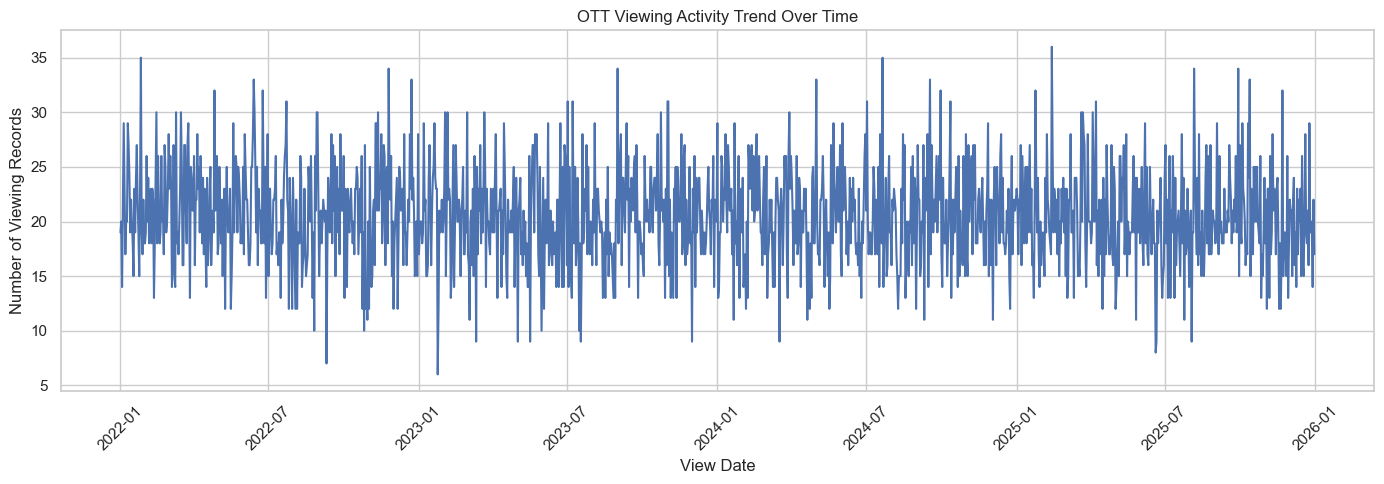

In [30]:
# ============================================================
# LINE CHART – VIEWING ACTIVITY TREND
# ============================================================

viewing_trend = viewing_activity.copy()

viewing_trend["View_Date"] = pd.to_datetime(
    viewing_trend["View_Date"],
    errors="coerce"
)

daily_views = (
    viewing_trend
    .dropna(subset=["View_Date"])
    .groupby("View_Date")
    .size()
    .reset_index(name="Viewing_Records")
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_views["View_Date"],
    daily_views["Viewing_Records"]
)

plt.title("OTT Viewing Activity Trend Over Time")
plt.xlabel("View Date")
plt.ylabel("Number of Viewing Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Narration

The line chart shows how OTT viewing activity changes over time. Peaks indicate periods of higher viewing activity, while declines may represent periods of lower engagement. This trend can help the platform understand viewing patterns and plan content releases or promotional campaigns.

## 11. BUSINESS QUESTION 1
### Which platforms generate the strongest viewing engagement?

**Visual:** Bar chart comparing total watch hours by platform.

**Narration:** Watch hours represent the amount of viewing time generated by each platform, so they provide a stronger engagement measure than raw view count alone.

**Key insight:** The platform comparison should distinguish between **traffic volume** and **engagement depth**.

,Total_Views,Watch_Hours,Avg_Completion
Platform,,,
NetStream,14174,"48,229.52",51.22
AmazePrime,13812,"34,359.92",53.02
DizPlay+,2014,"7,909.43",55.83


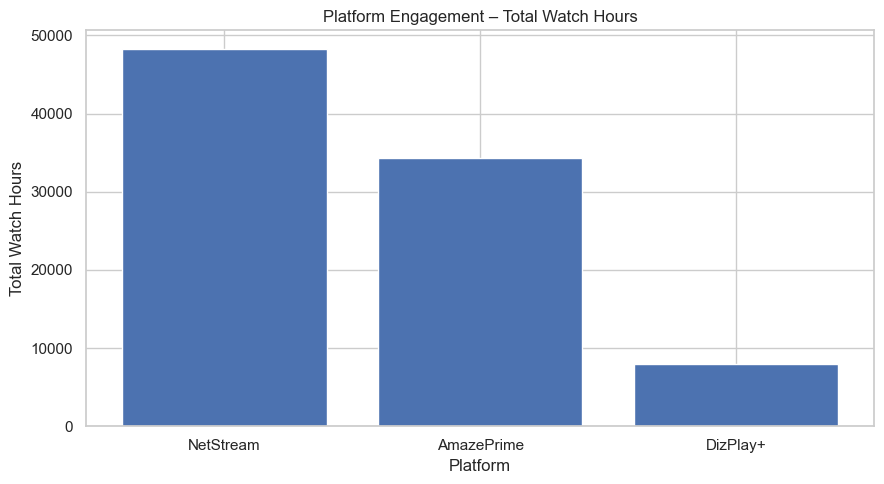

Narration: NetStream generates the highest total watch hours in the cleaned viewing data, making it the strongest platform by overall viewing time.


In [14]:
platform_perf = (
    analysis_df.groupby("Platform")
    .agg(
        Total_Views=("Viewing_Record_ID", "count"),
        Watch_Hours=("Watch_Duration_Minutes", lambda x: x.sum()/60),
        Avg_Completion=("Completion_Percentage", "mean")
    )
    .sort_values("Watch_Hours", ascending=False)
)

display(platform_perf.round(2))

plt.figure(figsize=(9, 5))
plt.bar(platform_perf.index, platform_perf["Watch_Hours"])
plt.title("Platform Engagement – Total Watch Hours")
plt.xlabel("Platform")
plt.ylabel("Total Watch Hours")
plt.tight_layout()
plt.show()

top_platform = platform_perf["Watch_Hours"].idxmax()
print(f"Narration: {top_platform} generates the highest total watch hours in the cleaned viewing data, "
      "making it the strongest platform by overall viewing time.")

## 12. BUSINESS QUESTION 2
### Do Movies or TV Shows generate more meaningful engagement?

**Visual:** Grouped bar chart for viewing records and watch hours.

**Narration:** Raw view counts and watch hours answer different questions. A format can attract many sessions but still generate less total viewing time.

**Key insight:** Compare both metrics before deciding which content type deserves stronger content investment.

,Viewing_Records,Watch_Hours,Avg_Completion
Content_Type,,,
Movie,21862,"17,924.00",53.22
TV Show,8138,"72,574.87",50.04


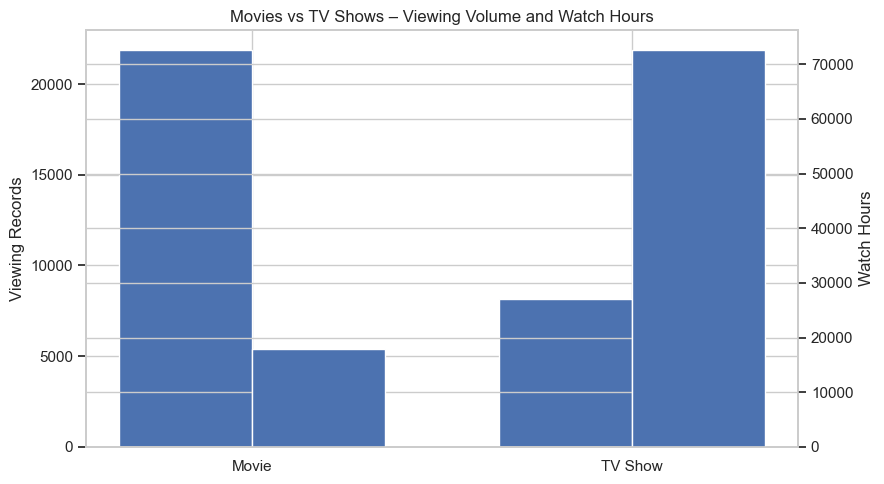

Narration: The content-type comparison reveals whether traffic volume and viewing-time engagement point to the same content format.


In [15]:
content_type_perf = (
    analysis_df.groupby("Content_Type")
    .agg(
        Viewing_Records=("Viewing_Record_ID", "count"),
        Watch_Hours=("Watch_Duration_Minutes", lambda x: x.sum()/60),
        Avg_Completion=("Completion_Percentage", "mean")
    )
)

display(content_type_perf.round(2))

fig, ax1 = plt.subplots(figsize=(9, 5))
x = np.arange(len(content_type_perf))
width = 0.35

ax1.bar(x - width/2, content_type_perf["Viewing_Records"], width, label="Viewing Records")
ax1.set_ylabel("Viewing Records")
ax1.set_xticks(x)
ax1.set_xticklabels(content_type_perf.index)

ax2 = ax1.twinx()
ax2.bar(x + width/2, content_type_perf["Watch_Hours"], width, label="Watch Hours")
ax2.set_ylabel("Watch Hours")

plt.title("Movies vs TV Shows – Viewing Volume and Watch Hours")
plt.tight_layout()
plt.show()

print("Narration: The content-type comparison reveals whether traffic volume and viewing-time engagement point to the same content format.")

## 13. BUSINESS QUESTION 3
### Which subscription plans have the highest churn risk?

**Visual:** Bar chart of churn rate by subscription type.

**Narration:** Churn rate measures the proportion of users in each subscription plan who are marked as churned. This is a direct retention KPI.

**Key insight:** A plan with unusually high churn should be treated as a retention-risk segment and investigated for onboarding, pricing or value-delivery issues.

,Users,Churn_Rate,Churn_Rate_%
Subscription_Type,,,
Free Trial,681,0.71,70.93
Basic,660,0.42,42.42
Premium,659,0.19,18.97


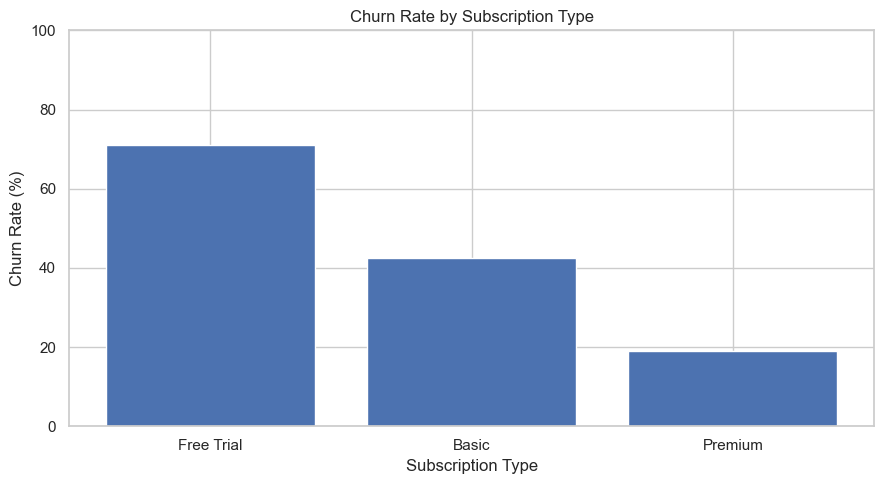

Key insight: Free Trial has the highest churn rate at 70.93%, making it the highest-priority subscription segment for retention action.


In [16]:
churn_by_plan = (
    subscription_retention.groupby("Subscription_Type")
    .agg(
        Users=("User_ID", "count"),
        Churn_Rate=("Churn_Flag", "mean")
    )
)

churn_by_plan["Churn_Rate_%"] = churn_by_plan["Churn_Rate"] * 100
churn_by_plan = churn_by_plan.sort_values("Churn_Rate_%", ascending=False)

display(churn_by_plan.round(2))

plt.figure(figsize=(9, 5))
plt.bar(churn_by_plan.index, churn_by_plan["Churn_Rate_%"])
plt.title("Churn Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

risk_plan = churn_by_plan["Churn_Rate_%"].idxmax()
risk_rate = churn_by_plan.loc[risk_plan, "Churn_Rate_%"]
print(f"Key insight: {risk_plan} has the highest churn rate at {risk_rate:.2f}%, making it the highest-priority subscription segment for retention action.")

## 14. BUSINESS QUESTION 4
### How does viewing behaviour differ between churned and retained users?

**Visual:** Boxplots comparing watch duration and completion for churned vs retained users.

**Narration:** Comparing engagement distributions helps determine whether churn is associated with noticeably different viewing behaviour.

**Key insight:** The difference should be interpreted as an association, not as proof that viewing behaviour causes churn.

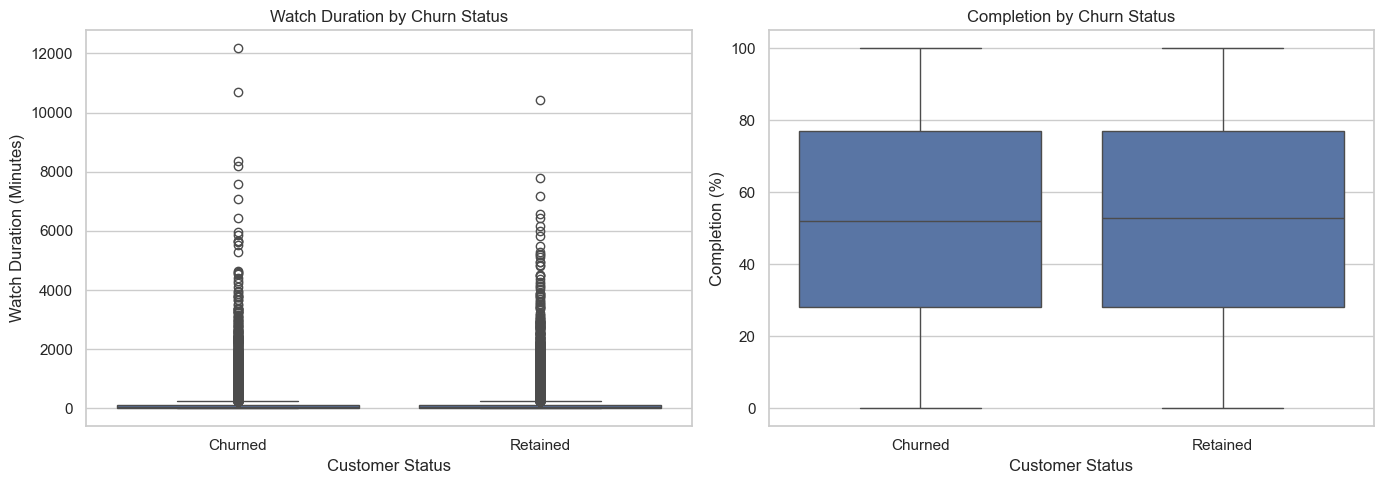

,Watch_Duration_Minutes,Completion_Percentage
Churn_Status,,
Churned,184.40,52.48
Retained,178.28,52.26


Narration: The boxplots show whether churned and retained users have different engagement distributions. This helps identify whether low-engagement users deserve targeted retention attention.


In [17]:
churn_labels = {0: "Retained", 1: "Churned"}
analysis_df["Churn_Status"] = analysis_df["Churn_Flag"].map(churn_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=analysis_df,
    x="Churn_Status",
    y="Watch_Duration_Minutes",
    ax=axes[0]
)
axes[0].set_title("Watch Duration by Churn Status")
axes[0].set_xlabel("Customer Status")
axes[0].set_ylabel("Watch Duration (Minutes)")

sns.boxplot(
    data=analysis_df,
    x="Churn_Status",
    y="Completion_Percentage",
    ax=axes[1]
)
axes[1].set_title("Completion by Churn Status")
axes[1].set_xlabel("Customer Status")
axes[1].set_ylabel("Completion (%)")

plt.tight_layout()
plt.show()

churn_behavior = analysis_df.groupby("Churn_Status")[
    ["Watch_Duration_Minutes", "Completion_Percentage"]
].mean()

display(churn_behavior.round(2))

print("Narration: The boxplots show whether churned and retained users have different engagement distributions. "
      "This helps identify whether low-engagement users deserve targeted retention attention.")

## 15. BUSINESS QUESTION 5
### Which genres attract the most viewing activity and watch hours?

**Visual:** Horizontal bar chart of top genres by viewing records/watch hours.

**Narration:** Genre-level analysis helps the content team identify categories with strong audience demand.

**Key insight:** Genre decisions should consider both the number of viewing records and the total watch time generated.

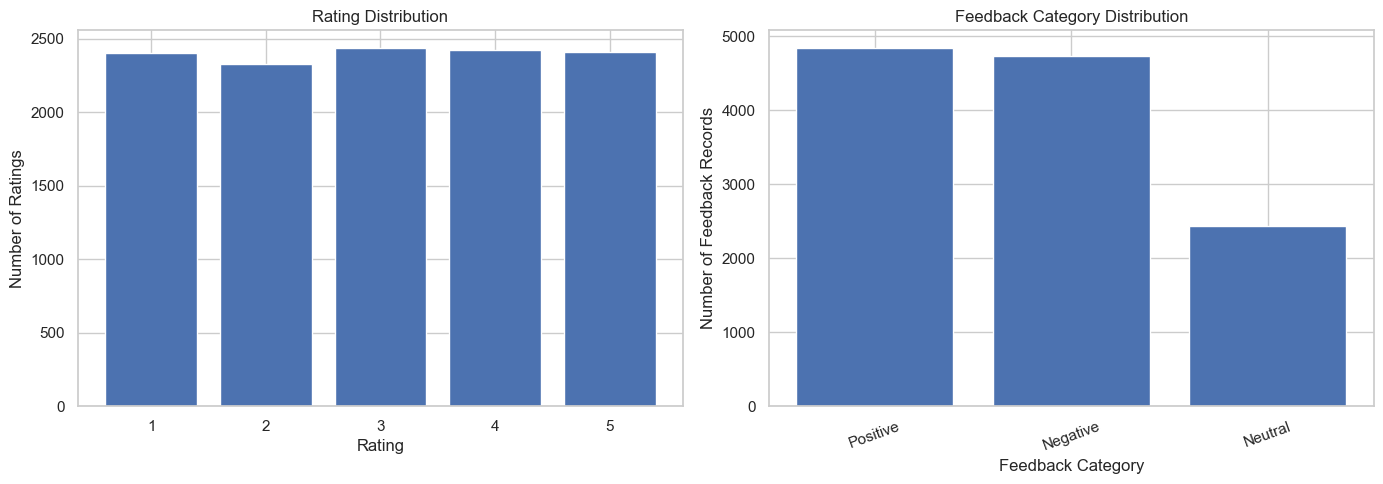

Average rating: 3.01
Feedback share (%):


Feedback_Category
Positive   40.30
Negative   39.42
Neutral    20.28
Name: count, dtype: float64

Key insight: Rating and feedback distributions provide the audience-satisfaction picture needed for content quality decisions.


In [18]:
rating_counts = ratings_feedback["Rating"].value_counts().sort_index()
feedback_counts = ratings_feedback["Feedback_Category"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(rating_counts.index.astype(str), rating_counts.values)
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Number of Ratings")

axes[1].bar(feedback_counts.index, feedback_counts.values)
axes[1].set_title("Feedback Category Distribution")
axes[1].set_xlabel("Feedback Category")
axes[1].set_ylabel("Number of Feedback Records")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print(f"Average rating: {ratings_feedback['Rating'].mean():.2f}")
print("Feedback share (%):")
display((feedback_counts / feedback_counts.sum() * 100).round(2))

print("Key insight: Rating and feedback distributions provide the audience-satisfaction picture needed for content quality decisions.")

## 16. BUSINESS QUESTION 6
### Which devices and times of day are associated with stronger completion?

**Visual:** Heatmap of average completion by device and time of day.

**Narration:** A device × time-of-day view reveals whether viewing context is associated with completion behaviour.

**Key insight:** The strongest cells can guide device-specific UX improvements, recommendations or notification timing.

Time_of_Day,Afternoon,Evening,Morning,Night
Device_Type,,,,
Laptop,51.09,53.21,53.02,53.01
Mobile,51.80,51.29,51.76,52.31
Smart TV,52.70,53.17,51.46,52.06
Tablet,52.41,52.48,52.69,53.35


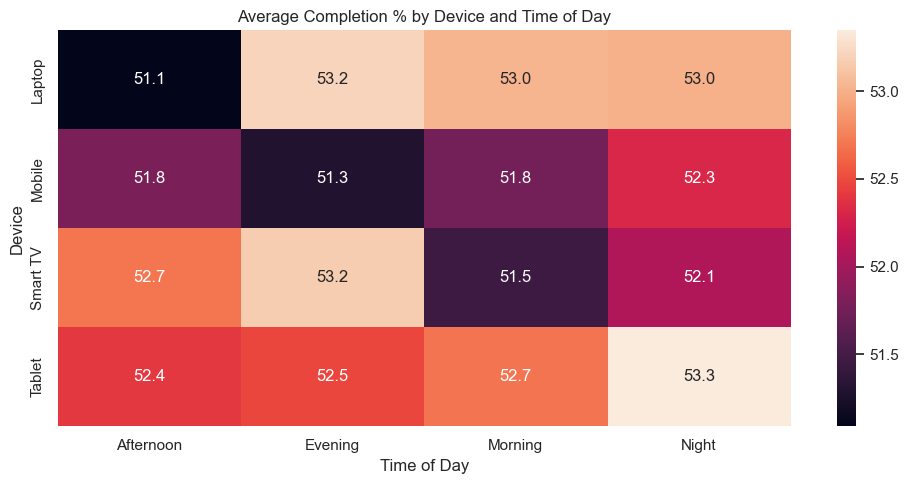

Key insight: The highest average completion occurs for Tablet users during the Night period (53.35%).


In [19]:
device_time = pd.pivot_table(
    viewing_activity,
    index="Device_Type",
    columns="Time_of_Day",
    values="Completion_Percentage",
    aggfunc="mean"
)

display(device_time.round(2))

plt.figure(figsize=(10, 5))
sns.heatmap(
    device_time,
    annot=True,
    fmt=".1f"
)
plt.title("Average Completion % by Device and Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Device")
plt.tight_layout()
plt.show()

max_cell = device_time.stack().idxmax()
max_value = device_time.loc[max_cell[0], max_cell[1]]
print(f"Key insight: The highest average completion occurs for {max_cell[0]} users during the {max_cell[1]} period ({max_value:.2f}%).")

## 17. BUSINESS QUESTION 7
### Does watch duration meaningfully relate to completion percentage?

**Visual:** Scatter plot with regression line.

**Narration:** This tests whether longer watch duration is strongly associated with higher completion.

**Key insight:** A statistically significant relationship can still be practically weak. Therefore, the correlation/R² value must be considered alongside the visual.

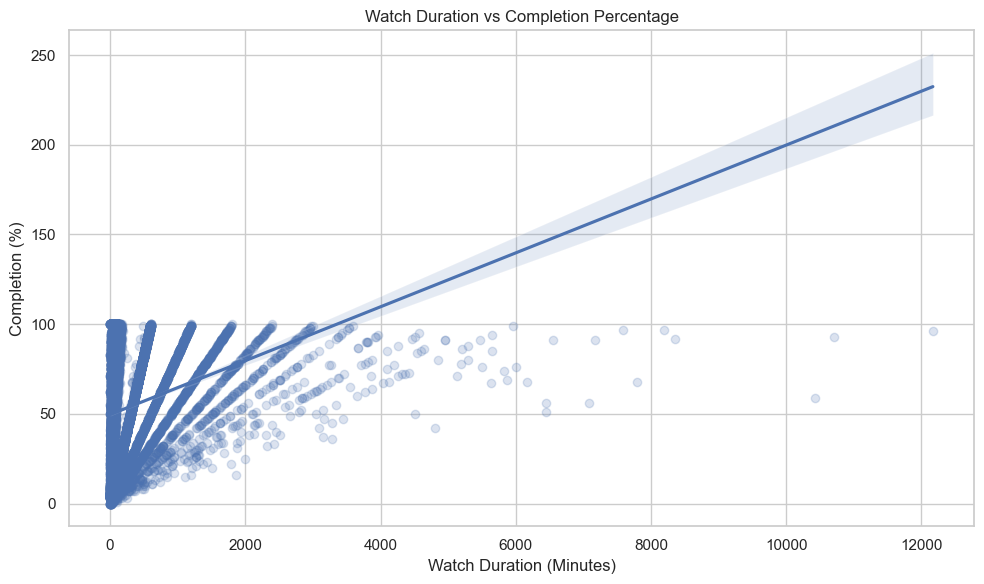

Correlation: 0.220
R²: 0.0486
Key insight: The relationship is positive but weak. Watch duration alone explains only a small part of the variation in completion, so other factors also influence completion behaviour.


In [20]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=viewing_activity,
    x="Watch_Duration_Minutes",
    y="Completion_Percentage",
    scatter_kws={"alpha": 0.20},
    line_kws={}
)
plt.title("Watch Duration vs Completion Percentage")
plt.xlabel("Watch Duration (Minutes)")
plt.ylabel("Completion (%)")
plt.tight_layout()
plt.show()

corr_value = viewing_activity[
    ["Watch_Duration_Minutes", "Completion_Percentage"]
].corr().iloc[0, 1]

r_squared = corr_value ** 2

print(f"Correlation: {corr_value:.3f}")
print(f"R²: {r_squared:.4f}")

print("Key insight: The relationship is positive but weak. Watch duration alone explains only a small part of the variation in completion, so other factors also influence completion behaviour.")

## 18. BUSINESS QUESTION 8
### What does audience rating and feedback reveal about content satisfaction?

**Visual:** Rating distribution + feedback category distribution.

**Narration:** Ratings and feedback provide direct audience-satisfaction signals. The combination is more informative than using a single average rating.

**Key insight:** A large positive-feedback share supports audience satisfaction, while negative feedback identifies areas requiring content or experience investigation.

,Viewing_Records,Watch_Hours,Avg_Completion
Genre,,,
International TV Shows,2302,"16,532.15",48.92
TV Dramas,1266,"11,374.07",48.92
Drama,5231,"11,342.02",52.46
TV Comedies,951,"10,696.15",50.46
Kids,1903,"8,586.22",55.23
Comedy,3564,"8,083.92",54.06
Crime TV Shows,812,"7,011.87",49.94
Kids' TV,734,"6,855.23",49.25
Docuseries,854,"6,829.55",49.70


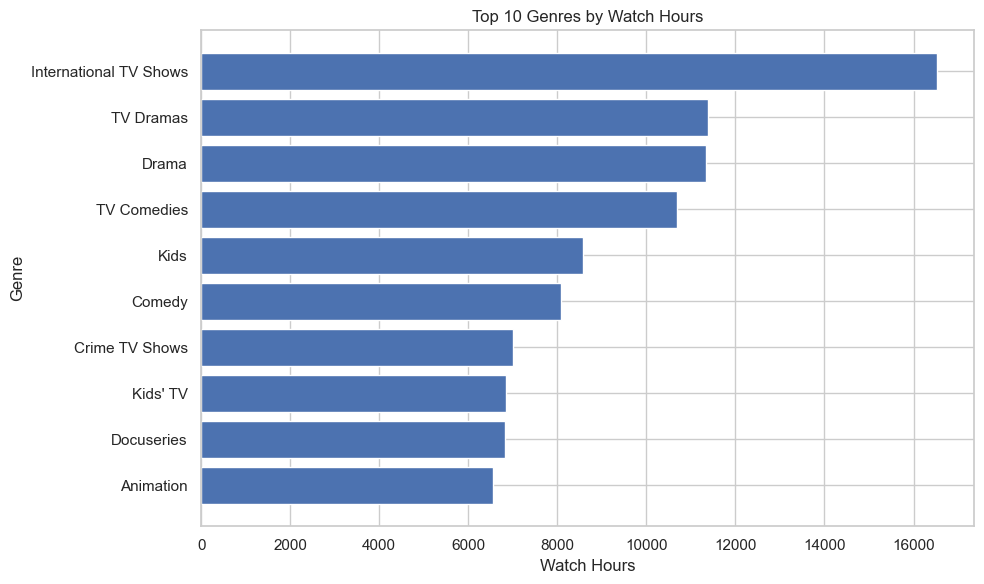

Key insight: International TV Shows generates the highest watch hours among the analysed genres.


In [21]:
genre_df = content_library[["Content_ID", "Genres", "Platform", "Content_Type"]].copy()
genre_df["Genre"] = genre_df["Genres"].fillna("Unknown").str.split(", ")
genre_df = genre_df.explode("Genre")

genre_views = viewing_activity.merge(
    genre_df[["Content_ID", "Genre"]],
    on="Content_ID",
    how="left"
)

genre_perf = (
    genre_views.groupby("Genre")
    .agg(
        Viewing_Records=("Viewing_Record_ID", "count"),
        Watch_Hours=("Watch_Duration_Minutes", lambda x: x.sum()/60),
        Avg_Completion=("Completion_Percentage", "mean")
    )
    .sort_values("Watch_Hours", ascending=False)
    .head(10)
)

display(genre_perf.round(2))

plt.figure(figsize=(10, 6))
plt.barh(genre_perf.index[::-1], genre_perf["Watch_Hours"][::-1])
plt.title("Top 10 Genres by Watch Hours")
plt.xlabel("Watch Hours")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

top_genre = genre_perf["Watch_Hours"].idxmax()
print(f"Key insight: {top_genre} generates the highest watch hours among the analysed genres.")

# 19. SUPPORTING ANALYSIS – AGE GROUP × ENGAGEMENT × CHURN

This is a useful multivariate view for identifying retention opportunities without overcrowding the dashboard.

,,Users,Churn_Rate,Churn_Rate_%
Age_Group,Engagement_Level,,,
26-35,Medium,165,0.54,53.94
36-50,High,161,0.51,50.93
18-25,Low,160,0.47,46.88
26-35,Low,179,0.46,45.81
36-50,Low,166,0.46,45.78
18-25,Medium,177,0.44,44.07
50+,Medium,171,0.42,42.11
36-50,Medium,181,0.42,41.99
50+,High,174,0.42,41.95


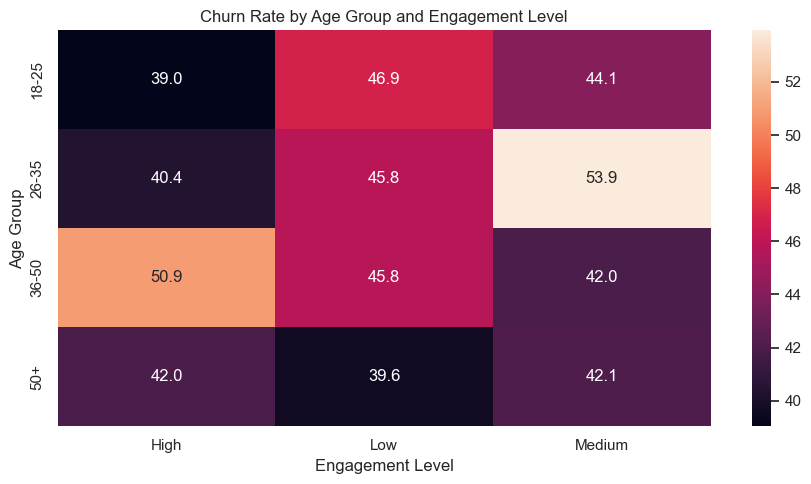

Narration: This multivariate view highlights combinations of audience characteristics where churn is comparatively high. It is better suited for deeper analysis than the minimal executive dashboard.


In [22]:
age_engagement_churn = (
    user_profile.merge(
        subscription_retention[["User_ID", "Churn_Flag"]],
        on="User_ID",
        how="left"
    )
    .groupby(["Age_Group", "Engagement_Level"])
    .agg(
        Users=("User_ID", "count"),
        Churn_Rate=("Churn_Flag", "mean")
    )
)

age_engagement_churn["Churn_Rate_%"] = age_engagement_churn["Churn_Rate"] * 100

display(
    age_engagement_churn.sort_values("Churn_Rate_%", ascending=False).round(2)
)

heat = age_engagement_churn["Churn_Rate_%"].unstack()

plt.figure(figsize=(9, 5))
sns.heatmap(heat, annot=True, fmt=".1f")
plt.title("Churn Rate by Age Group and Engagement Level")
plt.xlabel("Engagement Level")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()

print("Narration: This multivariate view highlights combinations of audience characteristics where churn is comparatively high. "
      "It is better suited for deeper analysis than the minimal executive dashboard.")

# 20. OUTLIER ANALYSIS

Outliers are retained because the project cleaning approach is conservative. They are analysed rather than automatically deleted.

For `Watch_Duration_Minutes`, the IQR method is used:

- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 − Q1
- Upper bound = Q3 + 1.5 × IQR

The earlier project analysis identified unusually high watch-duration records; these may represent extreme/power-viewing behaviour rather than data errors.

Q1: 29.00
Q3: 116.25
IQR: 87.25
Lower Bound: -101.88
Upper Bound: 247.12
Outlier Count: 5,500


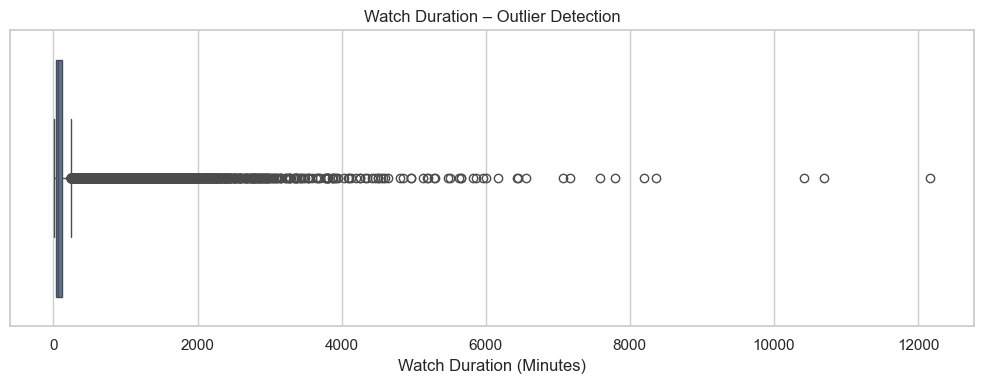

Narration: Extreme watch durations should be investigated as potential power-viewing behaviour. They are not removed merely because they are statistically unusual.


In [23]:
watch = viewing_activity["Watch_Duration_Minutes"]

Q1 = watch.quantile(0.25)
Q3 = watch.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = viewing_activity[
    (watch < lower_bound) | (watch > upper_bound)
]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"Outlier Count: {len(outliers):,}")

plt.figure(figsize=(10, 4))
sns.boxplot(x=watch)
plt.title("Watch Duration – Outlier Detection")
plt.xlabel("Watch Duration (Minutes)")
plt.tight_layout()
plt.show()

print("Narration: Extreme watch durations should be investigated as potential power-viewing behaviour. "
      "They are not removed merely because they are statistically unusual.")

# 21. DESCRIPTIVE STATISTICS

This section provides the core numerical framing required for EDA: mean, median, standard deviation, variance, skewness and kurtosis.

In [24]:
numeric_cols = [
    "Watch_Duration_Minutes",
    "Completion_Percentage",
    "Paused_Times"
]

stats = viewing_activity[numeric_cols].agg(
    ["count", "mean", "median", "std", "var", "min", "max", "skew", "kurt"]
).T

display(stats.round(3))

,count,mean,median,std,var,min,max,skew,kurt
Watch_Duration_Minutes,"30,000.00",181.00,61.00,412.24,"169,941.20",5.00,"12,169.00",7.99,114.06
Completion_Percentage,"30,000.00",52.36,53.00,28.08,788.66,0.00,100.00,-0.03,-1.19
Paused_Times,"30,000.00",1.50,1.00,1.12,1.26,0.00,3.00,0.01,-1.37


# 22. MINIMAL DASHBOARD – RECOMMENDED VISUALS

To keep the dashboard minimal and decision-focused, use **8 visuals/KPIs** rather than displaying every EDA chart.

| # | Business Question | Recommended Visual | Decision |
|---|---|---|---|
| 1 | Which platform has strongest engagement? | Bar chart – Watch Hours by Platform | Platform strategy |
| 2 | Movies vs TV Shows? | Clustered bar – Views + Watch Hours | Content investment |
| 3 | Which plan has highest churn? | Bar chart – Churn % by Plan | Retention action |
| 4 | Churned vs retained viewing? | Boxplots / KPI comparison | Engagement risk |
| 5 | Which genres perform best? | Top-10 horizontal bar | Content acquisition |
| 6 | Device × time completion? | Heatmap | UX / timing |
| 7 | Does watch time relate to completion? | Scatter + regression | Engagement diagnosis |
| 8 | What do ratings say? | Rating + feedback bars | Content quality |

### KPI cards for the top of the dashboard
- **Total Users:** 2,000
- **Total Viewing Records:** 30,000
- **Churn Rate:** 44%
- **Average Completion:** 52.36%
- **Average Rating:** 3.00
- **Total Watch Hours:** 90498.87

### Dashboard story
**Audience → Engagement → Content → Retention → Satisfaction**

This keeps the final dashboard aligned with the OTT business problem instead of becoming a collection of unrelated charts.

In [25]:
# ============================================================
# 23. FINAL KPI SUMMARY
# ============================================================
kpis = {
    "Total Users": user_profile["User_ID"].nunique(),
    "Viewing Records": viewing_activity["Viewing_Record_ID"].nunique(),
    "Total Content": content_library["Content_ID"].nunique(),
    "Total Ratings": len(ratings_feedback),
    "Churned Users": int(subscription_retention["Churn_Flag"].sum()),
    "Churn Rate %": subscription_retention["Churn_Flag"].mean() * 100,
    "Average Completion %": viewing_activity["Completion_Percentage"].mean(),
    "Average Rating": ratings_feedback["Rating"].mean(),
    "Total Watch Hours": viewing_activity["Watch_Duration_Minutes"].sum() / 60
}

kpi_df = pd.DataFrame(
    {"KPI": list(kpis.keys()), "Value": list(kpis.values())}
)

display(kpi_df.round(2))

print("Final EDA status: completed.")
print("The notebook uses the five cleaned datasets and focuses on business-question-driven visual analysis.")

,KPI,Value
0,Total Users,"2,000.00"
1,Viewing Records,"30,000.00"
2,Total Content,"17,797.00"
3,Total Ratings,"12,000.00"
4,Churned Users,888.00
5,Churn Rate %,44.40
6,Average Completion %,52.36
7,Average Rating,3.01
8,Total Watch Hours,"90,498.87"


Final EDA status: completed.
The notebook uses the five cleaned datasets and focuses on business-question-driven visual analysis.


# FINAL BUSINESS INSIGHTS

1. **Platform engagement is not just about view count.** Watch hours reveal which platform generates deeper viewing.
2. **Content type shows a volume-versus-engagement trade-off.** Movies can lead in viewing records while TV Shows can generate substantially more watch time.
3. **Subscription type is a major retention signal.** The highest-churn plan should receive priority retention attention.
4. **Churned and retained users can be compared through viewing behaviour**, but the relationship should be described as association rather than causation.
5. **Genre performance identifies content demand.** Top genres by watch hours can support acquisition and content planning.
6. **Device and time-of-day patterns can support experience optimisation.**
7. **Watch duration has a positive but weak relationship with completion**, so completion cannot be explained by watch duration alone.
8. **Ratings and feedback provide audience-satisfaction evidence** that can be combined with viewing engagement for content decisions.

> **Who watches → What they watch → How deeply they engage → What keeps them subscribed → How satisfied they are.**

**Note:** Statistical tests such as Z-test, T-test, Chi-square and regression belong in the separate statistical-analysis section of the capstone. This Sprint focuses on EDA and visualization.

# 24. FINAL INSIGHTS, RECOMMENDATIONS & ACTIONABLE INSIGHTS

| Business Area | Key Insight | Recommendation | Actionable Insight |
|---|---|---|---|
| Platform Engagement | NetStream generates the highest total watch hours (48,229.52 hours) and the highest viewing-record volume (14,174), making it the strongest platform by overall viewing depth. | Use NetStream as a benchmark for understanding successful content and engagement patterns. | Analyse the content, genres and user segments contributing to NetStream's strong watch-time performance and replicate successful patterns across other platforms. |
| Content Type | Movies generate more viewing records (21,862), while TV Shows generate substantially more watch hours (72,574.87). This shows a clear volume-versus-engagement difference. | Maintain a balanced content strategy instead of judging performance only by view count. | Promote Movies for traffic acquisition while prioritising high-performing TV Shows for deeper engagement and sustained viewing. |
| Subscription & Churn | Overall churn is 44.40%, with 888 churned users out of 2,000. Free Trial has the highest churn rate at 70.93%, making it the highest-priority retention segment. | Strengthen the Free Trial-to-paid conversion and early engagement strategy. | Introduce personalised content recommendations, onboarding messages and targeted offers before the trial period ends. |
| Age × Engagement × Churn | The highest-risk segment is users aged 26–35 with Medium engagement, with a churn rate of 53.94%. Users aged 36–50 with High engagement also show elevated churn of 50.93%. | Use targeted retention strategies instead of applying the same approach to all users. | Monitor high-risk age and engagement combinations and trigger personalised retention campaigns when engagement starts declining. |
| Viewing Behaviour & Churn | Churned and retained users show differences in viewing behaviour, but the relationship should be interpreted as an association rather than proof that viewing behaviour causes churn. | Use viewing behaviour as one signal within a broader churn-monitoring framework. | Combine watch duration, completion, engagement level and subscription information to identify users who may need retention attention. |
| Genre Performance | International TV Shows generate the highest watch hours among the analysed genres (16,532.15 hours), followed by TV Dramas and Drama. | Prioritise genres that demonstrate strong watch-time demand while maintaining variety in the content catalogue. | Increase promotion and content discovery for high-watch-hour genres and evaluate whether similar content can increase engagement. |
| Audience Satisfaction | The average audience rating is 3.01 out of 5. Ratings and feedback provide direct signals of content satisfaction. | Use rating and feedback data together with viewing behaviour rather than relying only on average ratings. | Identify content receiving low ratings or negative feedback and investigate whether content quality, relevance or user experience needs improvement. |
| Device & Time of Day | Device and time-of-day combinations show different completion levels. Tablet users during the Night period have the highest observed average completion at 53.35%. | Optimise recommendations and user experience according to viewing context. | Schedule relevant recommendations or notifications around high-engagement device/time combinations and investigate lower-performing combinations. |
| Completion Behaviour | Overall average completion is 52.36%, indicating that users complete only about half of the content on average. | Focus on improving content discovery and matching users with relevant content. | Use personalised recommendations based on viewing history, genre preference and previous completion behaviour. |
| Watch Duration & Completion | Watch duration has a positive but weak relationship with completion (correlation = 0.220; R² = 0.0486). Watch duration alone explains only a small portion of completion behaviour. | Do not use watch duration as the sole predictor of completion. | Include additional factors such as content type, genre, device, time of day and user engagement level when analysing or predicting completion. |
| Viewing Trends | Line-chart analysis of viewing records and watch hours helps identify periods of higher and lower audience activity. | Align content promotion and campaign timing with observed viewing patterns. | Use high-activity periods for major content promotions and investigate low-activity periods for opportunities to increase engagement. |
| Outliers / Power Users | Extreme watch-duration observations represent unusual viewing behaviour and may indicate power users or exceptionally long sessions. | Retain and investigate unusual observations rather than automatically deleting them. | Segment extreme viewers separately to understand binge-watching behaviour and consider personalised recommendations for these users. |
| Overall Business Strategy | The analysis shows that traffic volume, engagement depth, satisfaction and retention are different dimensions of OTT performance. | Build decisions using multiple KPIs rather than a single metric. | Monitor watch hours, completion, ratings, churn, content performance and audience segments together through the dashboard. |

## Overall Business Conclusion

The OTT analysis shows that successful platform performance cannot be measured using viewing volume alone. Movies attract a larger number of viewing records, while TV Shows generate substantially greater watch time. NetStream leads overall engagement by watch hours, while Free Trial users represent the highest retention risk with a 70.93% churn rate. Genre, device, time-of-day, audience satisfaction and demographic engagement patterns provide additional opportunities for targeted decisions.

The most important business priority is therefore to **increase engagement while reducing churn through personalised content recommendations, targeted retention campaigns and data-driven content planning**. The findings also show that no single variable explains user behaviour completely; combining engagement, content, audience and retention metrics provides a stronger basis for OTT decision-making.

In [26]:
pip install streamlit pandas openpyxl seaborn matplotlib plotly

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.1 MB 22.6 MB/s eta 0:00:01
   ------ --------------------------------- 1.6/9.1 MB 4.8 MB/s eta 0:00:02
   ---------- ----------------------------- 2.4/9.1 MB 4.3 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.1 MB 4.2 MB/s eta 0:00:02
   ----------------- ---------------------- 3.9/9.1 MB 4.1 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.1 MB 4.1 MB/s eta 0:00:02
   ------------------------ --------------- 5.5/9.1 MB 4.1 MB/s eta 0:00:01
   --------------------------- ------------ 6.3/9.1 MB 4.0 MB/s eta 0:00:01
   ------------------------------- -------- 7.1/9.1 MB 4.0 MB/s eta 0:00:01
   ---------------------------------- ----- 7.9/9.1 MB 4.0 MB/s eta 0:00:01
   -------------------------------------- - 8.7/9.1 MB 4.0 MB/s eta 0:00:01
   -------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
fruits = set()

def add_fruit(fruit_name, price):
    fruits.add((fruit_name, price))
    return fruits

print(add_fruit("Apple", 100))
print(add_fruit("Banana", 50))
print(add_fruit("Apple", 100))

{('Apple', 100)}
{('Apple', 100), ('Banana', 50)}
{('Apple', 100), ('Banana', 50)}
